<a href="https://colab.research.google.com/github/pdkoumudi2510/MYFIRSTPROJECT_2026/blob/main/COVID19_Complete_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# COVID-19 complete project (Google Colab)

**One notebook:** load `covid_19.csv` once, then run **summary table**, **three pie charts**, and **ML** (metrics + confusion matrices).

## How to run in Colab
1. Upload this `.ipynb` to Colab (**File → Upload notebook**).
2. **Runtime → Run all**.
3. **Data file:** either upload `covid_19.csv` via the **Files** sidebar to `/content/` *before* running, **or** use the upload prompt in the load cell.

If the file is already at `/content/covid_19.csv`, the notebook loads it automatically (good for **Run all**).


In [1]:
# !pip install -q pandas numpy scikit-learn matplotlib seaborn

import io
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    from google.colab import files

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)

try:
    from IPython.display import display
except ImportError:
    display = print  # rare: plain script

print("Libraries loaded. Next cell loads covid_19.csv.")


Libraries loaded. Next cell loads covid_19.csv.


## 1. Load `covid_19.csv`


In [2]:
COLAB_CSV = Path("/content/covid_19.csv")

if COLAB_CSV.is_file():
    df = pd.read_csv(COLAB_CSV)
    print("Loaded from session:", COLAB_CSV)
elif IN_COLAB:
    uploaded = files.upload()
    if "covid_19.csv" not in uploaded:
        raise FileNotFoundError("Please upload a file named exactly: covid_19.csv")
    df = pd.read_csv(io.BytesIO(uploaded["covid_19.csv"]))
    print("Loaded from upload.")
else:
    p = Path("covid_19.csv")
    if not p.is_file():
        raise FileNotFoundError(
            "Place covid_19.csv next to this notebook, or run in Google Colab."
        )
    df = pd.read_csv(p)
    print("Loaded (local):", p.resolve())

print("Shape:", df.shape)
df.head()


Saving covid_19.csv to covid_19.csv
Loaded from upload.
Shape: (238, 9)


,country,continent,population,day,time,Cases,Recovered,Deaths,Tests
0,Saint-Helena,Africa,6115.0,2024-06-30,2024-06-30T16:15:16+00:00,2166,2.0,NaN,NaN
1,Falkland-Islands,South-America,3539.0,2024-06-30,2024-06-30T16:15:16+00:00,1930,1930.0,NaN,8632.0
2,Montserrat,North-America,4965.0,2024-06-30,2024-06-30T16:15:16+00:00,1403,1376.0,8.0,17762.0
3,Diamond-Princess,NaN,NaN,2024-06-30,2024-06-30T16:15:16+00:00,712,699.0,13.0,NaN
4,Vatican-City,Europe,799.0,2024-06-30,2024-06-30T16:15:16+00:00,29,29.0,NaN,NaN


---
## Part A — Summary by continent

Sums **Cases**, **Deaths**, and **population** over countries in each continent (excludes `All` and missing `continent`).


In [3]:
agg = (
    df.groupby("continent", dropna=False)[["Cases", "Deaths", "population"]]
    .sum(numeric_only=True)
    .rename(
        columns={
            "Cases": "total_cases",
            "Deaths": "total_deaths",
            "population": "total_population",
        }
    )
)
summary = agg.loc[agg.index.notna() & (agg.index != "All")].copy()
summary = summary.sort_values("total_cases", ascending=False)
summary["total_cases"] = summary["total_cases"].astype("int64")
summary["total_deaths"] = summary["total_deaths"].fillna(0).round().astype("int64")
summary["total_population"] = summary["total_population"].fillna(0).round().astype("int64")

display(summary)
summary.to_csv("continent_covid_summary.csv", encoding="utf-8")
if IN_COLAB:
    files.download("continent_covid_summary.csv")
    print("Triggered download: continent_covid_summary.csv")
else:
    print("Wrote: continent_covid_summary.csv")

excluded = agg.loc[(agg.index.isna()) | (agg.index == "All")]
if not excluded.empty:
    print("Excluded (aggregate / unknown continent):")
    display(excluded)


,total_cases,total_deaths,total_population
continent,,,
Europe,506812396,4203648,747543837
Asia,443000530,3107324,4711356783
North-America,263778264,3391882,598140916
South-America,140401758,2734664,437694443
Oceania,29791542,66030,43470408
Africa,25721848,517784,1406728744


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Triggered download: continent_covid_summary.csv
Excluded (aggregate / unknown continent):


,total_cases,total_deaths,total_population
continent,,,
All,704753890,7010681.0,0.0
NaN,721,15.0,0.0


---
## Part B — Pie charts (Cases, Deaths, Population)

Same continent **color** in all three pies. Figure shows inline; PNG download runs after `plt.show()` in Colab.


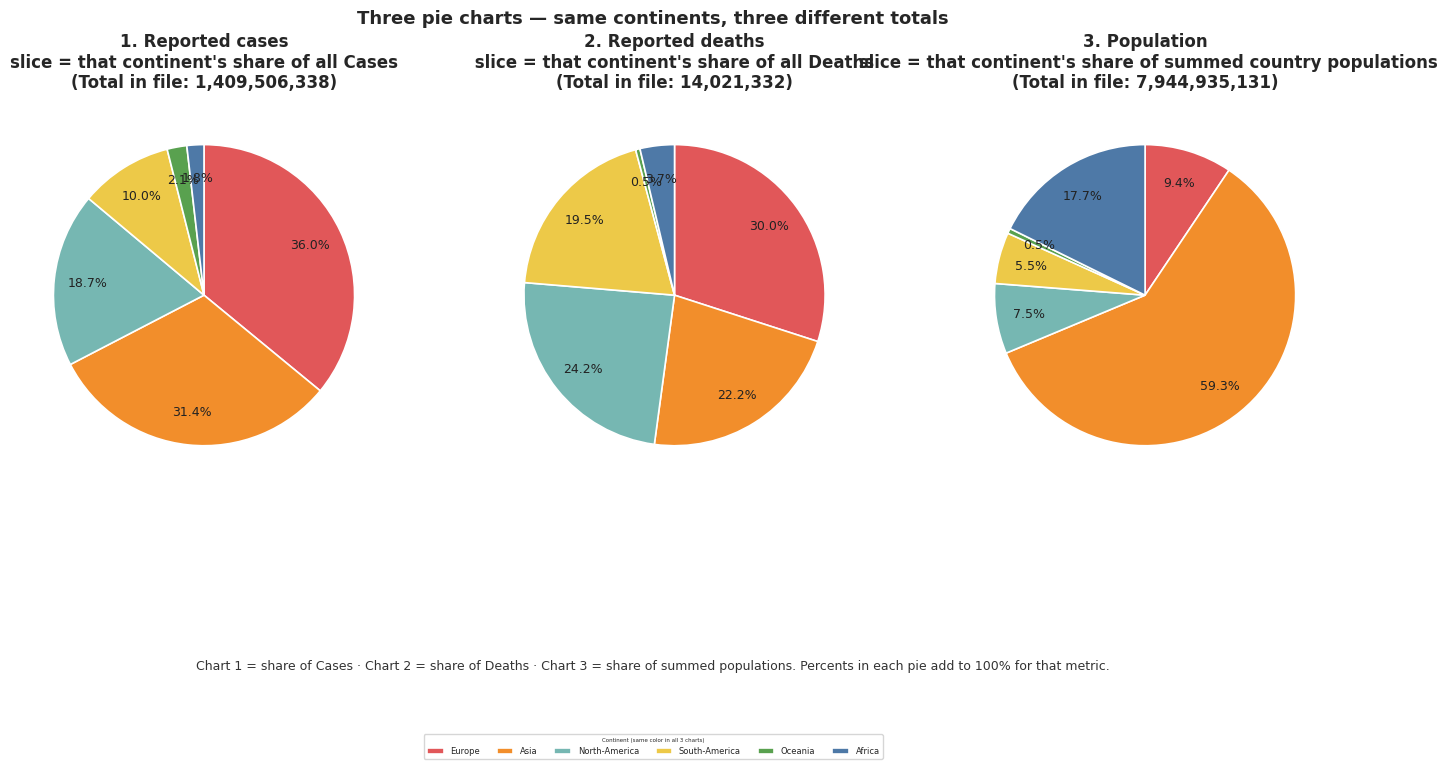

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Triggered download: continent_pie_charts.png


In [12]:
CONTINENT_COLORS = {
    "Africa": "#4E79A7",
    "Asia": "#F28E2B",
    "Europe": "#E15759",
    "North-America": "#76B7B2",
    "Oceania": "#59A14F",
    "South-America": "#EDC948",
}
FALLBACK = ["#B07AA1", "#FF9DA7", "#9C755F", "#BAB0AC"]

sub = df[df["continent"].notna() & (df["continent"] != "All")]
totals = (
    sub.groupby("continent")[["Cases", "Deaths", "population"]]
    .sum(numeric_only=True)
    .fillna(0)
)
totals.columns = ["cases", "deaths", "population"]
totals = totals.sort_values("cases", ascending=False)
labels = totals.index.tolist()
colors = [
    CONTINENT_COLORS.get(n, FALLBACK[i % len(FALLBACK)])
    for i, n in enumerate(labels)
]

fig, axes = plt.subplots(1, 3, figsize=(17, 6.5))
fig.patch.set_facecolor("white")


def fmt_pct(pct):
    return f"{pct:.1f}%"


def draw_pie(ax, values, panel_num, short_title, long_line):
    total = float(values.sum())
    wedges, _, autotexts = ax.pie(
        values,
        labels=None,
        autopct=fmt_pct,
        pctdistance=0.78,
        colors=colors,
        startangle=90,
        counterclock=False,
        wedgeprops=dict(edgecolor="white", linewidth=1.2),
        textprops={"fontsize": 10},
    )
    ax.set_title(
        f"{panel_num}. {short_title}\n{long_line}\n(Total in file: {total:,.0f})",

        fontsize=12,
        pad=14,
        fontweight="semibold",
    )
    for t in autotexts:
        t.set_color("#222222")
        t.set_fontsize(9)
    return wedges


wedges_legend = draw_pie(
    axes[0],
    totals["cases"],
    1,
    "Reported cases",
    "slice = that continent's share of all Cases",
)
draw_pie(
    axes[1],
    totals["deaths"],
    2,
    "Reported deaths",
    " slice = that continent's share of all Deaths ",
)
draw_pie(
    axes[2],
    totals["population"],
    3,
    "Population",
    " slice = that continent's share of summed country populations",
)

leg = fig.legend(
    wedges_legend,
    labels,
    title="Continent (same color in all 3 charts)",
    loc="lower center",
    ncol=6,
    fontsize=6,
    title_fontsize=4,
    frameon=True,
    fancybox=True,
    bbox_to_anchor=(0.5, -0.14),
)
leg.get_frame().set_edgecolor("#cccccc")

fig.suptitle(
    "Three pie charts — same continents, three different totals",
    fontsize=13,
    fontweight="bold",
    y=1.02,
)
fig.text(
    0.5,
    0.005,
    "Chart 1 = share of Cases · Chart 2 = share of Deaths · Chart 3 = share of summed populations. "
    "Percents in each pie add to 100% for that metric.",
    ha="center",
    fontsize=9,
    color="#333333",
)
plt.subplots_adjust(bottom=0.28, top=0.88, wspace=0.25)
plt.show()

fig.savefig("continent_pie_charts.png", dpi=200, bbox_inches="tight", facecolor="white")
if IN_COLAB:
    files.download("continent_pie_charts.png")
    print("Triggered download: continent_pie_charts.png")
else:
    print("Wrote: continent_pie_charts.png")


---
## Part C — ML (`high_fatality`)

**Target:** case fatality (Deaths/Cases) **above the training-split median** (median fit on train only; same threshold labels test rows).

**Features:** `population`, `Cases`, `Recovered`, `Tests`, `cases_per_mil`, `tests_per_mil`, `recovery_rate` — **not** raw `Deaths`.

**Models:** Logistic Regression + HistGradientBoosting.


### C1 — Dtypes and missing values


In [13]:
print("=== dtypes ===")
print(df.dtypes)
miss = df.isna().sum().sort_values(ascending=False)
miss_pct = (100 * miss / len(df)).round(2)
m = pd.DataFrame({"missing": miss, "pct": miss_pct})
display(m[m["missing"] > 0])


=== dtypes ===
country        object
continent      object
population    float64
day            object
time           object
Cases           int64
Recovered     float64
Deaths        float64
Tests         float64
dtype: object


,missing,pct
Recovered,48,20.17
Tests,25,10.50
population,9,3.78
Deaths,5,2.10
continent,2,0.84


### C2 — Clean, features, train/test split


In [14]:
df_clean = df.copy()
df_clean = df_clean[df_clean["continent"].notna()]
df_clean = df_clean[df_clean["continent"] != "All"]
df_clean = df_clean.drop_duplicates(subset=["country"], keep="last")

pop = df_clean["population"].replace(0, np.nan)
df_clean["cases_per_mil"] = (df_clean["Cases"] / (pop / 1e6)).replace([np.inf, -np.inf], np.nan)
df_clean["tests_per_mil"] = (df_clean["Tests"] / (pop / 1e6)).replace([np.inf, -np.inf], np.nan)
df_clean["recovery_rate"] = np.where(
    df_clean["Cases"] > 0, df_clean["Recovered"] / df_clean["Cases"], np.nan
)
df_clean["death_rate"] = np.where(
    df_clean["Cases"] > 0, df_clean["Deaths"] / df_clean["Cases"], np.nan
)

df_ml = df_clean[np.isfinite(df_clean["death_rate"])].reset_index(drop=True)

feature_cols = [
    "population",
    "Cases",
    "Recovered",
    "Tests",
    "cases_per_mil",
    "tests_per_mil",
    "recovery_rate",
]
X_all = df_ml[feature_cols]

idx = np.arange(len(df_ml))
train_idx, test_idx = train_test_split(
    idx, test_size=0.25, random_state=42, shuffle=True
)

median_train_death_rate = df_ml.iloc[train_idx]["death_rate"].median()
y_train = (df_ml.iloc[train_idx]["death_rate"] > median_train_death_rate).astype(int)
y_test = (df_ml.iloc[test_idx]["death_rate"] > median_train_death_rate).astype(int)

X_train = X_all.iloc[train_idx]
X_test = X_all.iloc[test_idx]

print("ML rows:", len(df_ml), "| train:", len(train_idx), "| test:", len(test_idx))
print("Train median death_rate (threshold):", median_train_death_rate)


ML rows: 230 | train: 172 | test: 58
Train median death_rate (threshold): 0.008309663254290812


### C3 — Train models


In [15]:
numeric_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)
preprocess = ColumnTransformer(
    transformers=[("num", numeric_pipe, feature_cols)],
    remainder="drop",
)
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=8000, class_weight="balanced", random_state=42
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        learning_rate=0.08,
        max_depth=8,
        max_iter=500,
        min_samples_leaf=2,
        random_state=42,
    ),
}
fitted = {}
for name, clf in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocess), ("model", clf)])
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
print("Training complete.")


Training complete.


### C4 — Metrics (test set)


In [17]:
class_names = ["low_fatality (0)", "high_fatality (1)"]
for name, pipe in fitted.items():
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1b = f1_score(y_test, y_pred, average="binary")
    print(f"\n========== {name} ==========")
    print(f"Accuracy:    {acc:.4f}")
    print(f"F1 (binary): {f1b:.4f}")
    print(classification_report(y_test, y_pred, target_names=class_names, digits=3, zero_division=0))


========== Logistic Regression ==========
Accuracy:    0.8103
F1 (binary): 0.8533
                   precision    recall  f1-score   support

 low_fatality (0)      0.750     0.714     0.732        21
high_fatality (1)      0.842     0.865     0.853        37

         accuracy                          0.810        58
        macro avg      0.796     0.790     0.793        58
     weighted avg      0.809     0.810     0.809        58


========== HistGradientBoosting ==========
Accuracy:    0.7759
F1 (binary): 0.8060
                   precision    recall  f1-score   support

 low_fatality (0)      0.643     0.857     0.735        21
high_fatality (1)      0.900     0.730     0.806        37

         accuracy                          0.776        58
        macro avg      0.771     0.793     0.770        58
     weighted avg      0.807     0.776     0.780        58



### C5 — Confusion matrices


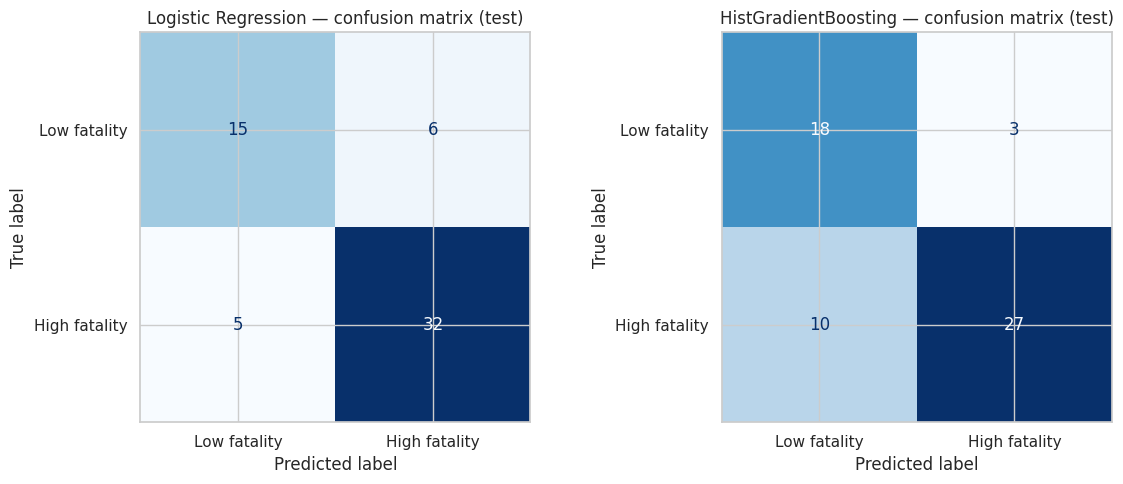

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, pipe) in zip(axes, fitted.items()):
    y_pred = pipe.predict(X_test)
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=["Low fatality", "High fatality"],
        cmap="Blues",
        colorbar=False,
        ax=ax,
    )
    ax.set_title(f"{name} — confusion matrix (test)")
plt.tight_layout()
plt.show()


---
| Section | What you get |
|---------|----------------|
| Part A | Table + `continent_covid_summary.csv` |
| Part B | Inline figure + `continent_pie_charts.png` |
| Part C | Accuracy / F1 / report + confusion matrices |

Works in **Google Colab** and **Jupyter** (uses `IPython.display.display` for tables).
